In [1]:
%matplotlib inline
from matplotlib import pyplot as plt
import numpy as np
import pygtc


<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


In [2]:
pygtc.__version__


'0.4.1'

In [6]:
model40_dir = '../Kepler68_final_RVs_LARGERrange/model040/dynesty_plot/planet_samples/'
model41_dir = '../Kepler68_final_RVs_LARGERrange/model041/dynesty_plot/planet_samples/'

model40_all = '../Kepler68_final_RVs_LARGERrange/model040/dynesty_plot/all_samples/'
model41_all = '../Kepler68_final_RVs_LARGERrange/model041/dynesty_plot/all_samples/'

In [7]:
 -165.101218+360


194.898782

In [20]:
e_P = np.genfromtxt(model40_dir + 'e_P.dat')
e_e = np.genfromtxt(model40_dir + 'e_e.dat')
e_o = np.genfromtxt(model40_dir + 'e_omega.dat')
e_K = np.genfromtxt(model40_dir + 'e_K.dat')
e_AU = np.genfromtxt(model40_dir + 'e_a_AU_(M).dat')

sel = (e_o<0.)
e_o[sel] += 360.

n_sam = len(e_P)
model40_samples = np.zeros([n_sam, 5])
model40_samples[:,0] = e_P
model40_samples[:,1] = e_e
model40_samples[:,2] = e_o
model40_samples[:,3] = e_K
model40_samples[:,4] = e_AU * (1-e_e)


In [21]:
e_P = np.genfromtxt(model41_dir + 'e_P.dat')
e_e = np.genfromtxt(model41_dir + 'e_e.dat')
e_o = np.genfromtxt(model41_dir + 'e_omega.dat')
e_K = np.genfromtxt(model41_dir + 'e_K.dat')
e_AU = np.genfromtxt(model41_dir + 'e_a_AU_(M).dat')

sel = (e_o<0.)
e_o[sel] += 360.

n_sam = len(e_P)
model41_samples = np.zeros([n_sam, 5])
model41_samples[:,0] = e_P
model41_samples[:,1] = e_e
model41_samples[:,2] = e_o
model41_samples[:,3] = e_K
model41_samples[:,4] = e_AU * (1-e_e)




findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.


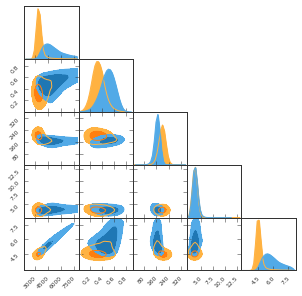

In [10]:
GTC = pygtc.plotGTC(chains=[model40_samples,model41_samples])


findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.


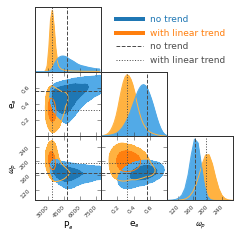

In [11]:
# List of parameter names, supports latex
# NOTE: For capital greek letters in latex mode, use \mathsf{}
names = ['P$_e$',
         'e$_e$',
         '$\omega_p$']

# Labels for the different chains
chainLabels = ["no trend",
               "with linear trend"]


# Labels for the different truths
truthLabels = ( 'no trend',
               'with linear trend')

truths = ((4844.912303,  0.559476,  167.252484), (3431.635459, 0.320151, 194.898782))


# List of parameter ranges to show,
# empty () or None to let pyGTC decide
paramRanges = ((),
               (0.0, 0.80),
               (90,270))

GTC = pygtc.plotGTC(chains=[model40_samples[:,:3],model41_samples[:,:3]],
                    paramNames=names,
                    chainLabels=chainLabels,
                    truths=truths,
                    paramRanges=paramRanges,
                    figureSize='AandA_column',
                    truthLabels=truthLabels,
                    nBins =40,
                    plotName='model4planets_GTC_Peo.pdf')


In [12]:
id_selection = np.ones_like(model40_samples[:,0], dtype=bool)
dist_array = np.zeros_like(model40_samples[:,0])

import os 
file_list = os.listdir(model40_all)
for filename in file_list:
    if filename[-4:] =='.png': continue
    if filename=='log_likelihood.dat': continue

    pam_vals = np.genfromtxt(model40_all+filename)
    pam_perc = np.percentile(pam_vals, [15.865, 50, 84.135], axis=0)
    id_selection = (id_selection) & ((pam_vals > pam_perc[0]) &  (pam_vals < pam_perc[2]) )
    
    #dist_array += (pam_vals/pam_perc[1] - 1.)**2
    #print(np.sum(id_selection))

    dist_array += ((pam_vals-pam_perc[1])/(pam_perc[2]-pam_perc[0]))**2

#dist = (model40_samples[id_selection,0]/4500 -1)**2 + (model40_samples[id_selection,1]/0.5 -1)**2 
id_val = np.argmin(dist_array)
print(model40_samples[id_val,:])

#[4.22515838e+03 4.82624397e-01 1.66160109e+02]


[4.72124271e+03 4.94625024e-01 1.65834756e+02 3.82078913e+00
 5.62820026e+00]


In [13]:
id_selection = np.ones_like(model41_samples[:,0], dtype=bool)
dist_array = np.zeros_like(model41_samples[:,0])

import os 
file_list = os.listdir(model41_all)
for filename in file_list:
    if filename[-4:] =='.png': continue
    if filename=='log_likelihood.dat': continue

    pam_vals = np.genfromtxt(model41_all+filename)
    pam_perc = np.percentile(pam_vals, [15.865, 50, 84.135], axis=0)
    id_selection = (id_selection) & ((pam_vals > pam_perc[0]) &  (pam_vals < pam_perc[2]) )
    
    dist_array += ((pam_vals-pam_perc[1])/(pam_perc[2]-pam_perc[0]))**2
    
    #dist_array += (pam_vals/pam_perc[1] - 1.)**2


id_val = np.argmin(dist_array)
print(model41_samples[id_val,:])


[3.54622609e+03 2.27081497e-01 1.98330522e+02 3.64752492e+00
 4.64289181e+00]


In [14]:
aa = np.zeros([5,6])
a = np.shape(aa)[0]
for ia, va in enumerate(aa):
    print(va, ia)
out = np.percentile(aa, [15.865, 50, 84.135], axis=0)
print(out[:,0])
np.shape(out)

[0. 0. 0. 0. 0. 0.] 0
[0. 0. 0. 0. 0. 0.] 1
[0. 0. 0. 0. 0. 0.] 2
[0. 0. 0. 0. 0. 0.] 3
[0. 0. 0. 0. 0. 0.] 4
[0. 0. 0.]


(3, 6)

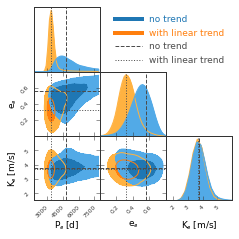

In [15]:
# List of parameter names, supports latex
# NOTE: For capital greek letters in latex mode, use \mathsf{}
names = ['P$_e$ [d]',
         'e$_e$',
         'K$_e$ [m/s]']

# Labels for the different chains
chainLabels = ["no trend",
               "with linear trend"]


truths = ((4844.912303,  0.559476, 3.76), (3431.635459, 0.320151, 3.70))

# Labels for the different truths
truthLabels = ( 'no trend',
               'with linear trend')

# List of parameter ranges to show,
# empty () or None to let pyGTC decide
paramRanges = ((),
               (0.0, 0.80),
               (1.5,6))

GTC = pygtc.plotGTC(chains=[model40_samples[:,[0,1,3]],model41_samples[:,[0,1,3]]],
                    paramNames=names,
                    chainLabels=chainLabels,
                    truths=truths,
                    paramRanges=paramRanges,
                    figureSize='AandA_column',
                    truthLabels=truthLabels,
                    nBins =40,
                    #colorsOrder=('yellows_old','purples'),
                    plotName='model4planets_GTC_PeK.pdf')
#Bad color name in colorsOrder=('C0', 'C2'), pick from dict_keys(['blues_old', 'greens_old', 
#'yellows_old', 'reds_old', 'purples_old', 'blues', 'oranges', 'greens', 'reds',
#'purples', 'browns', 'pinks', 'grays', 'yellows', 'cyans

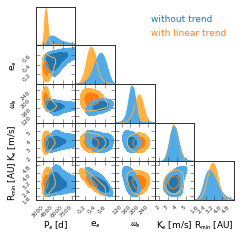

In [23]:
# List of parameter names, supports latex
# NOTE: For capital greek letters in latex mode, use \mathsf{}
names = ['P$_e$ [d]',
         'e$_e$',
         '$\omega_e$',
         'K$_e$ [m/s]',
        'R$_\mathrm{min}$ [AU]']

# Labels for the different chains
chainLabels = ["without trend",
               "with linear trend"]

truths = ((4844.912303,  0.559476, 167.252484, 3.76), (3431.635459, 0.320151,194.898782, 3.70))

# Labels for the different truths
truthLabels = ( 'no trend',
               'with linear trend')

# List of parameter ranges to show,
# empty () or None to let pyGTC decide
paramRanges = ((),
               (0.0, 0.80),
               (90,270),
               (1.5,6),
               (1.2, 5.2))

#plt.rcParams['figure.dpi'] = 70

#truthColors (list-like[nTruths]) – User-defined colors for the truth lines, must be one per set of truths passed to truths. Default color is gray #4d4d4d for up to three lines.

#truthColors = ('#adadad', '#adadad')

#truthLineStyles (list-like[nTruths]) – User-defined line styles for the truth lines, must be one per set of truths passed to truths. Default line styles are ['--', ':', 'dashdot'].

truthLineStyles = ('dashed', 'dashdot')


GTC = pygtc.plotGTC(chains=[model40_samples,model41_samples],
                    paramNames=names,
                    chainLabels=chainLabels,
                    #truths=truths,
                    paramRanges=paramRanges,
                    figureSize='AandA_column',
                    #truthLabels=truthLabels,
                    #truthColors=truthColors,
                    #truthLineStyles=truthLineStyles,
                    nBins =40,
                    #colorsOrder=('yellows_old','purples'),
                    plotName='model4planets_GTC_PeoK.png')
#Bad color name in colorsOrder=('C0', 'C2'), pick from dict_keys(['blues_old', 'greens_old', 
#'yellows_old', 'reds_old', 'purples_old', 'blues', 'oranges', 'greens', 'reds',
#'purples', 'browns', 'pinks', 'grays', 'yellows', 'cyans